# Tree Categories Demo

Demonstrates the `tree_categories` function with different parameter values.

## Setup

In [1]:
import rioxarray as rxr

from shelterbelts.utils.visualisation import visualise_categories_sidebyside, visualise_categories
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.indices.tree_categories import tree_categories
from shelterbelts.indices.tree_categories import tree_categories_cmap, tree_categories_labels

# Load example data
binary_tree_file = get_filename('g2_26729_binary_tree_cover_10m.tiff')
da_trees = rxr.open_rasterio(binary_tree_file).isel(band=0).drop_vars('band')
ds_input = da_trees.to_dataset(name='woody_veg')
print(f"Input dimensions: {ds_input['woody_veg'].shape}")

Input dimensions: (201, 201)


## Default Parameters

In [2]:
ds_default = tree_categories(ds_input, stub='default')
ds_default

Saved: ./default_tree_categories.tif
Saved: ./default_tree_categories.png


<xarray.Dataset> Size: 84kB
Dimensions:          (x: 201, y: 201)
Coordinates:
  * x                (x) float64 2kB 6.3e+05 6.3e+05 ... 6.32e+05 6.32e+05
  * y                (y) float64 2kB 6.196e+06 6.196e+06 ... 6.194e+06 6.194e+06
    spatial_ref      int64 8B 0
Data variables:
    woody_veg        (y, x) uint8 40kB 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0
    tree_categories  (y, x) uint8 40kB 12 12 12 12 12 12 12 12 ... 0 0 0 0 0 0 0

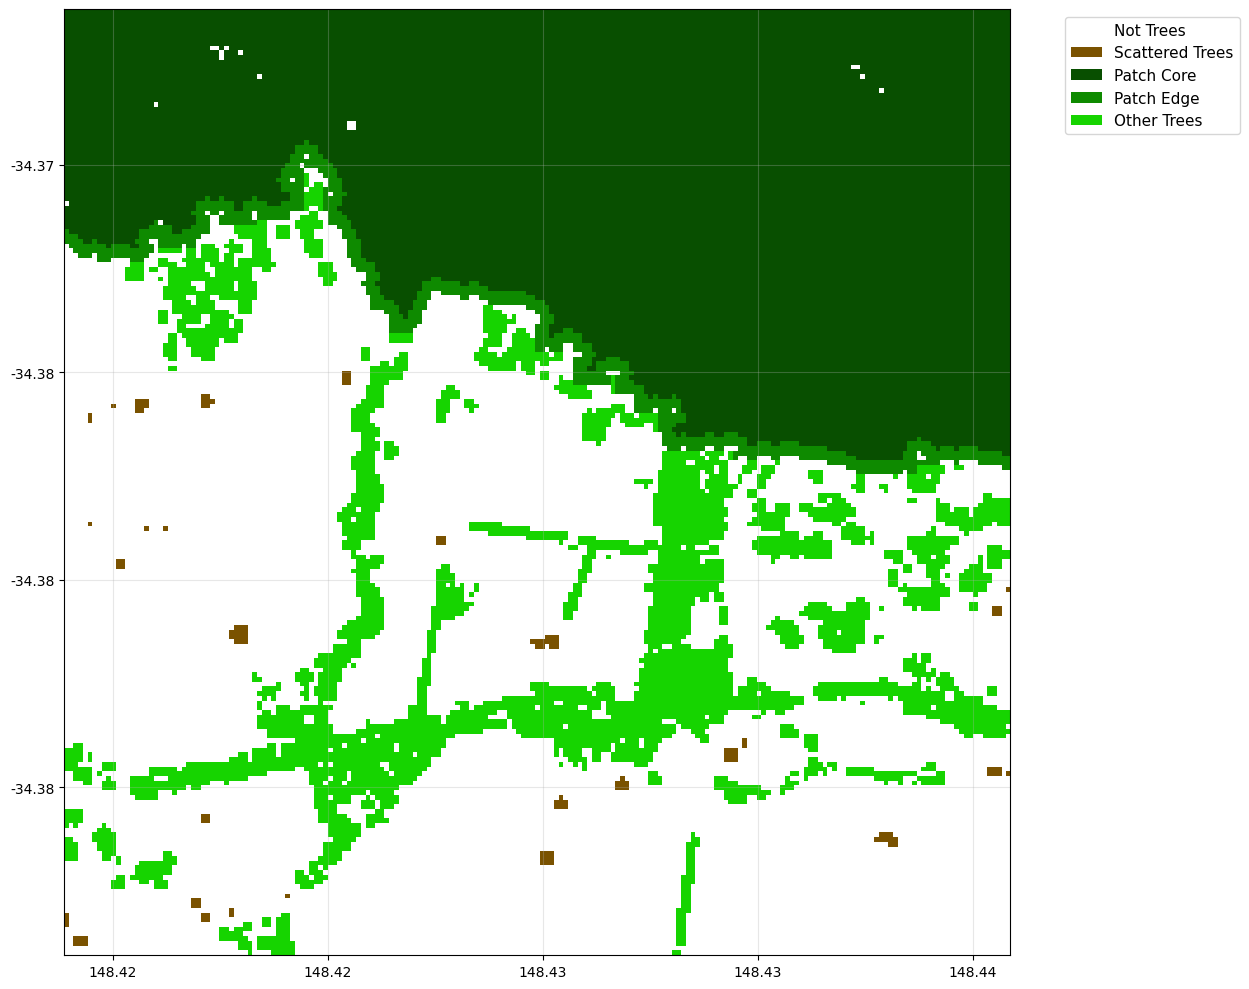

In [3]:
visualise_categories(
    ds_default['tree_categories'],
    colormap=tree_categories_cmap,
    labels=tree_categories_labels
)

## Changing the edge_size

The `edge_size` parameter defines the distance (in pixels) from the edge of a patch.
Areas beyond this distance from edges are classified as "Patch Core".

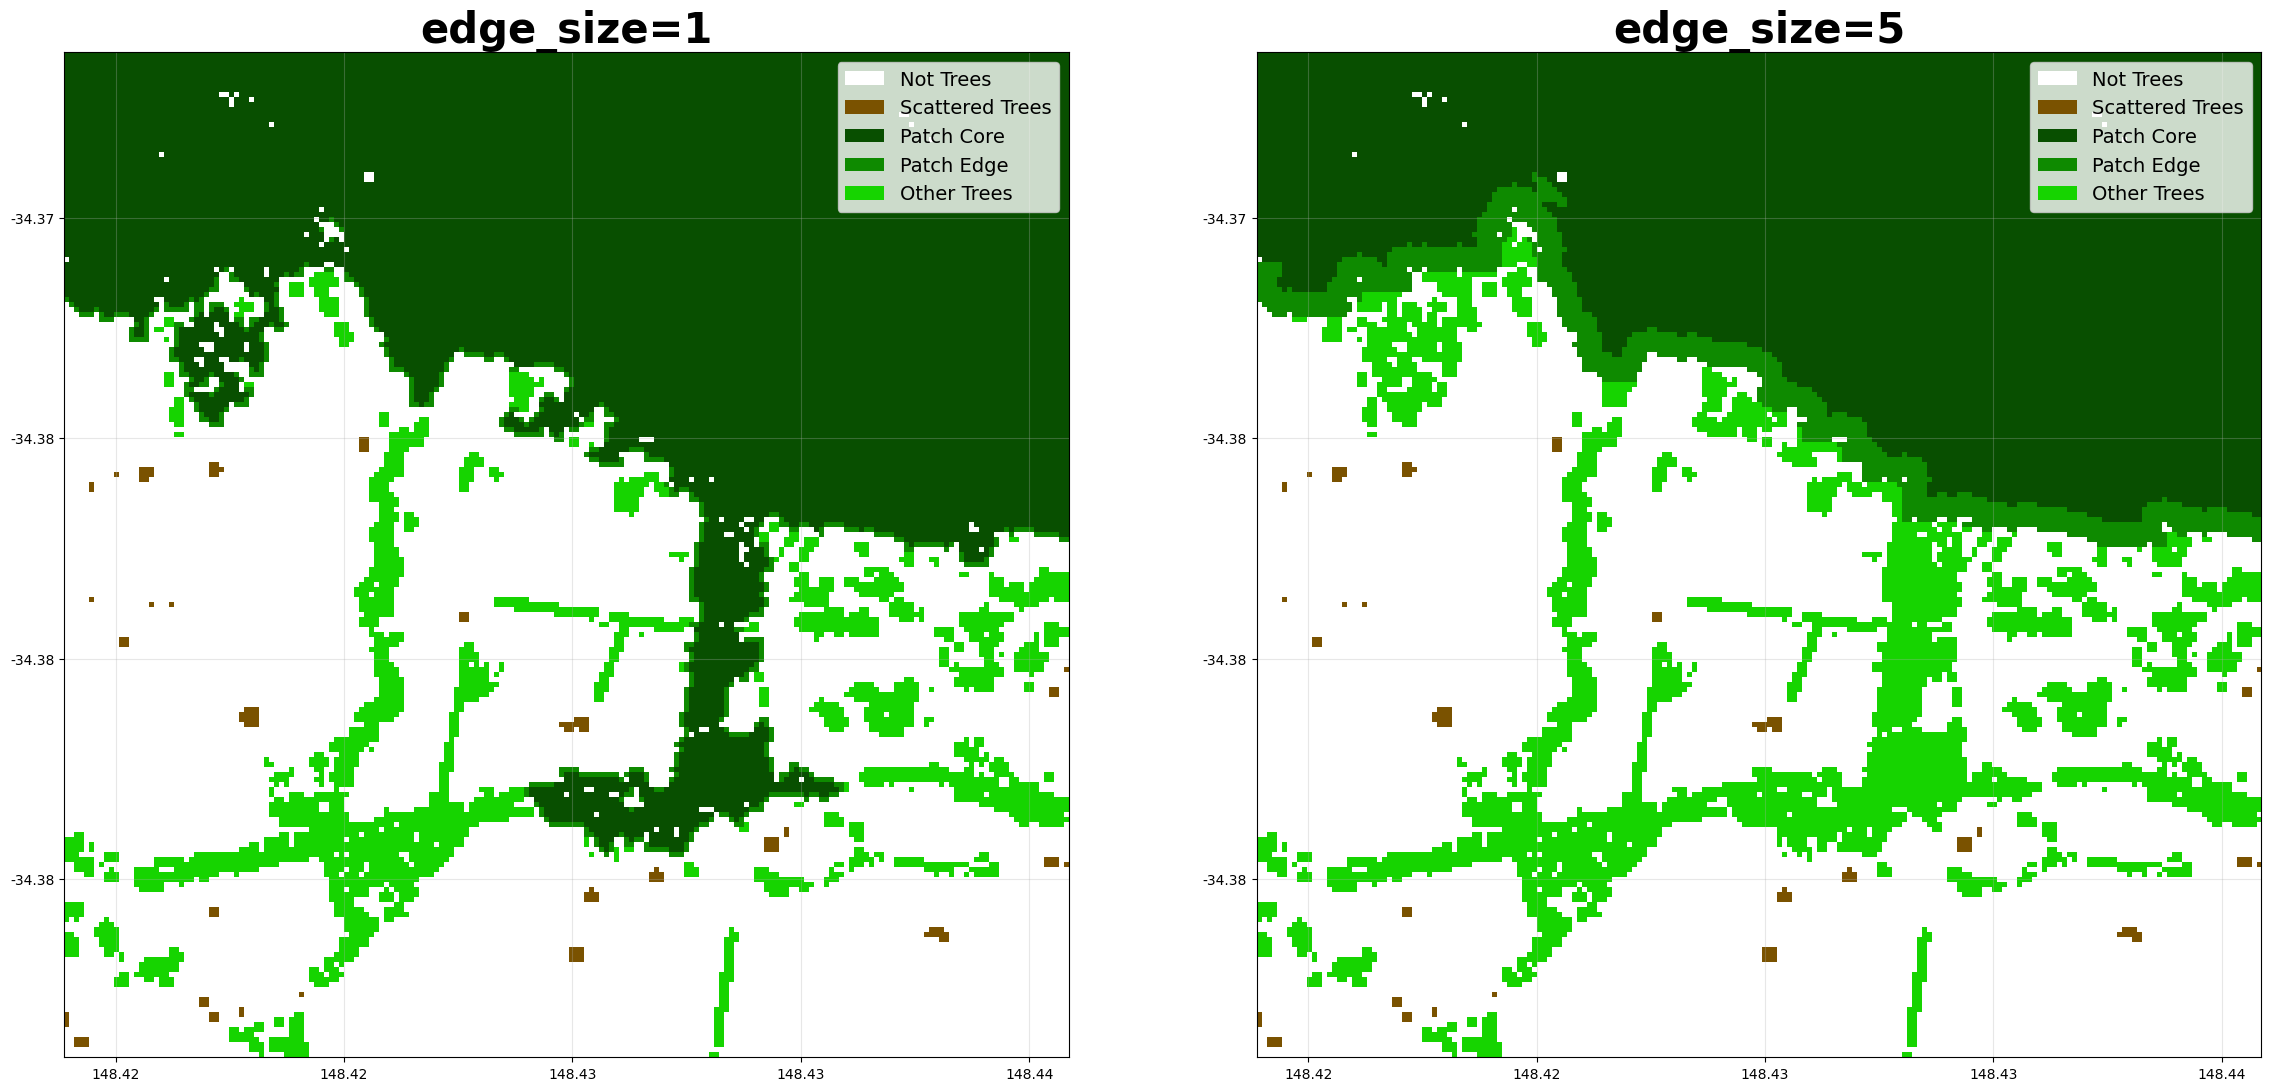

In [4]:
ds_edge1 = tree_categories(ds_input, stub='edge1', outdir='/tmp', plot=False, save_tif=False, edge_size=1)
ds_edge5 = tree_categories(ds_input, stub='edge5', outdir='/tmp', plot=False, save_tif=False, edge_size=5)

visualise_categories_sidebyside(
    ds_edge1['tree_categories'], ds_edge5['tree_categories'],
    colormap=tree_categories_cmap, labels=tree_categories_labels,
    title1="edge_size=1", title2="edge_size=5"
)

## Changing the min_patch_size

The `min_patch_size` parameter sets the minimum area (in pixels) for a cluster to be
considered a patch rather than scattered trees.

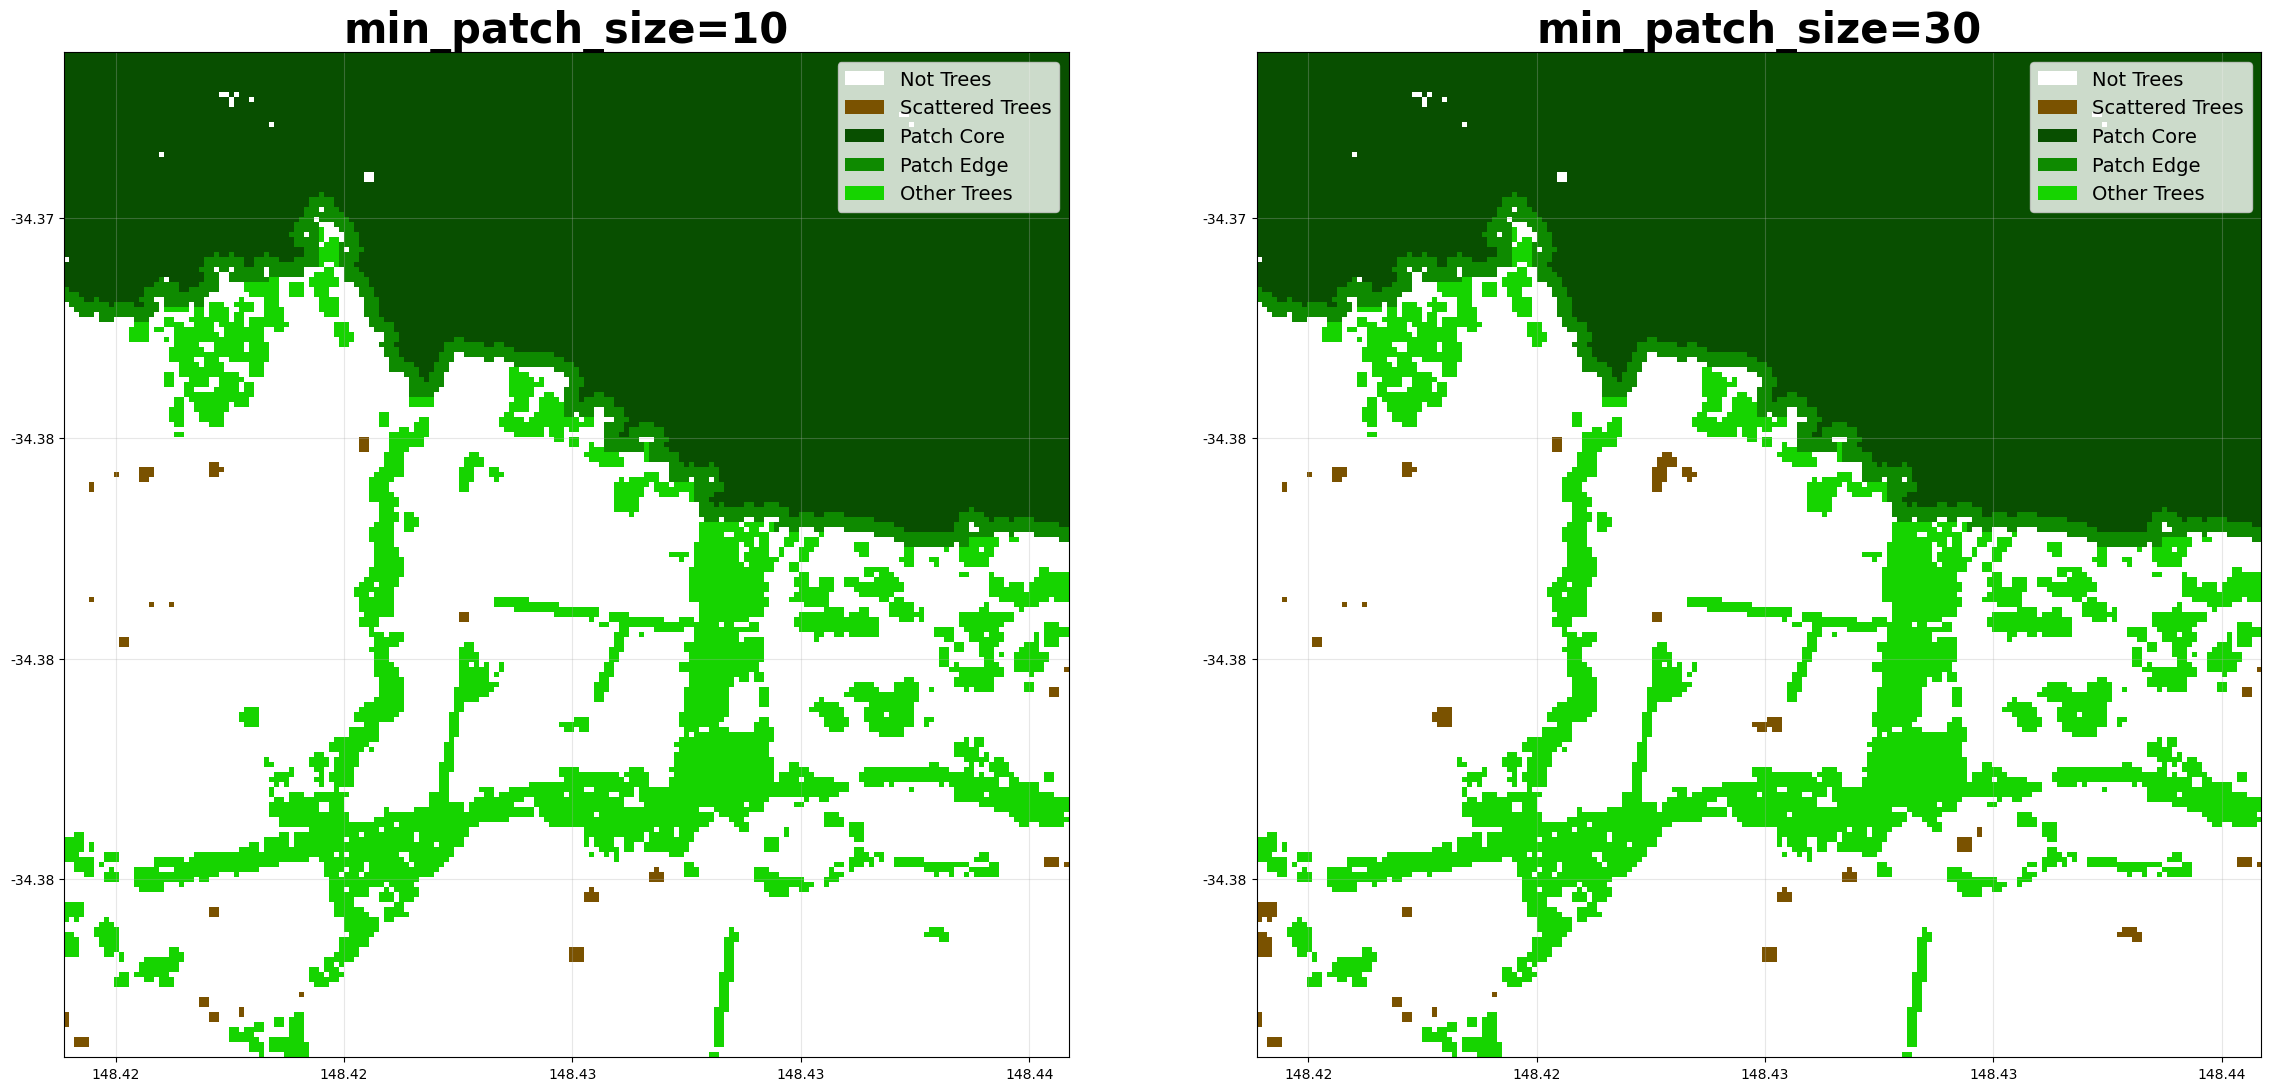

In [5]:
ds_patch10 = tree_categories(ds_input, stub='patch10', outdir='/tmp', plot=False, save_tif=False, min_patch_size=10)
ds_patch30 = tree_categories(ds_input, stub='patch30', outdir='/tmp', plot=False, save_tif=False, min_patch_size=30)

visualise_categories_sidebyside(
    ds_patch10['tree_categories'], ds_patch30['tree_categories'],
    colormap=tree_categories_cmap, labels=tree_categories_labels,
    title1="min_patch_size=10", title2="min_patch_size=30"
)

## Changing the max_gap_size

The `max_gap_size` parameter determines the maximum gap (in pixels) that can be bridged
when connecting tree clusters into patches.

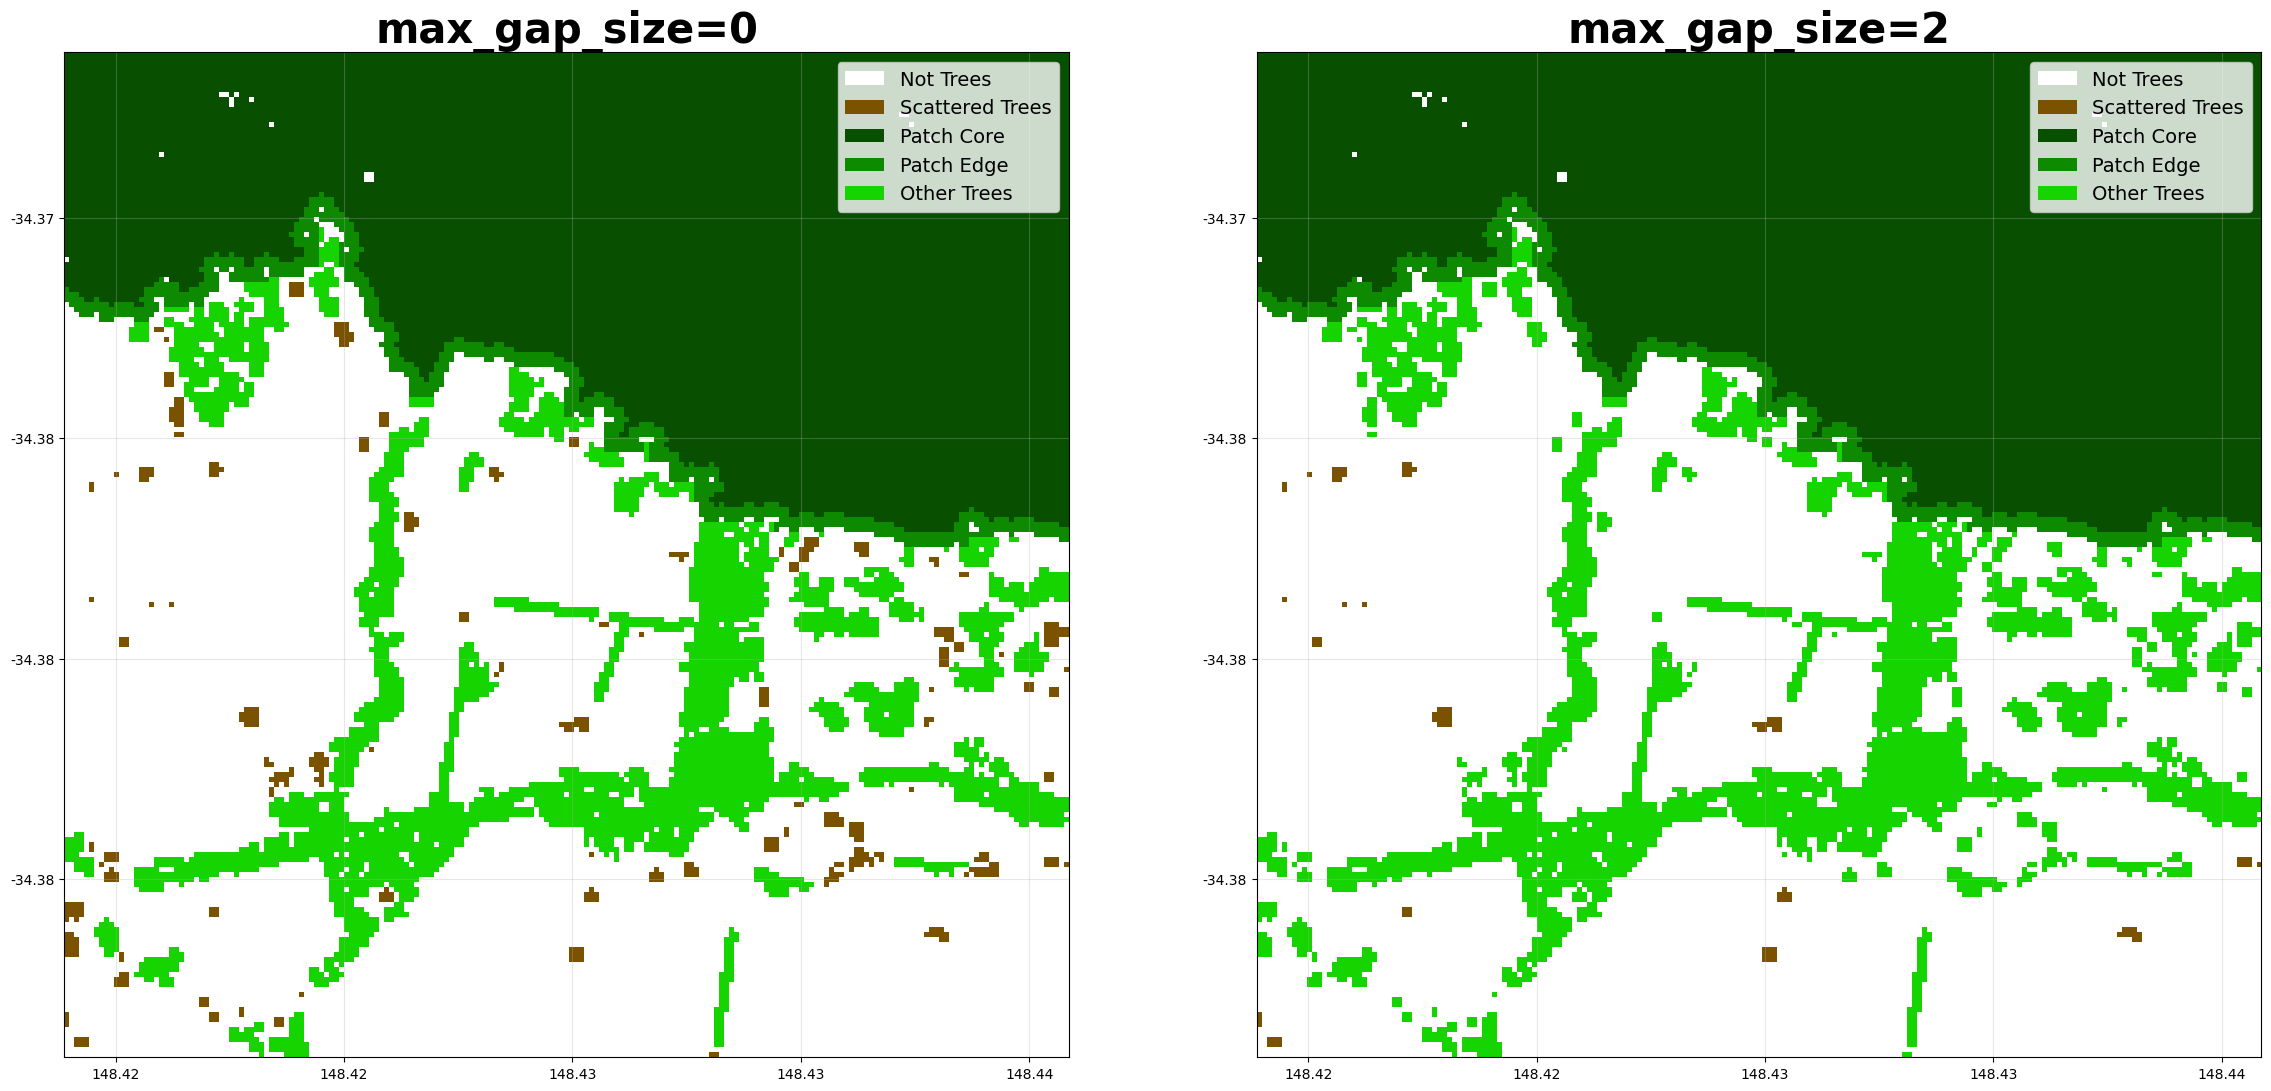

In [6]:
ds_gap0 = tree_categories(ds_input, stub='gap0', outdir='/tmp', plot=False, save_tif=False, max_gap_size=0)
ds_gap2 = tree_categories(ds_input, stub='gap2', outdir='/tmp', plot=False, save_tif=False, max_gap_size=2)

visualise_categories_sidebyside(
    ds_gap0['tree_categories'], ds_gap2['tree_categories'],
    colormap=tree_categories_cmap, labels=tree_categories_labels,
    title1="max_gap_size=0", title2="max_gap_size=2"
)

## Changing the strict_core_area method

The `strict_core_area` parameter changes the method for defining core areas.

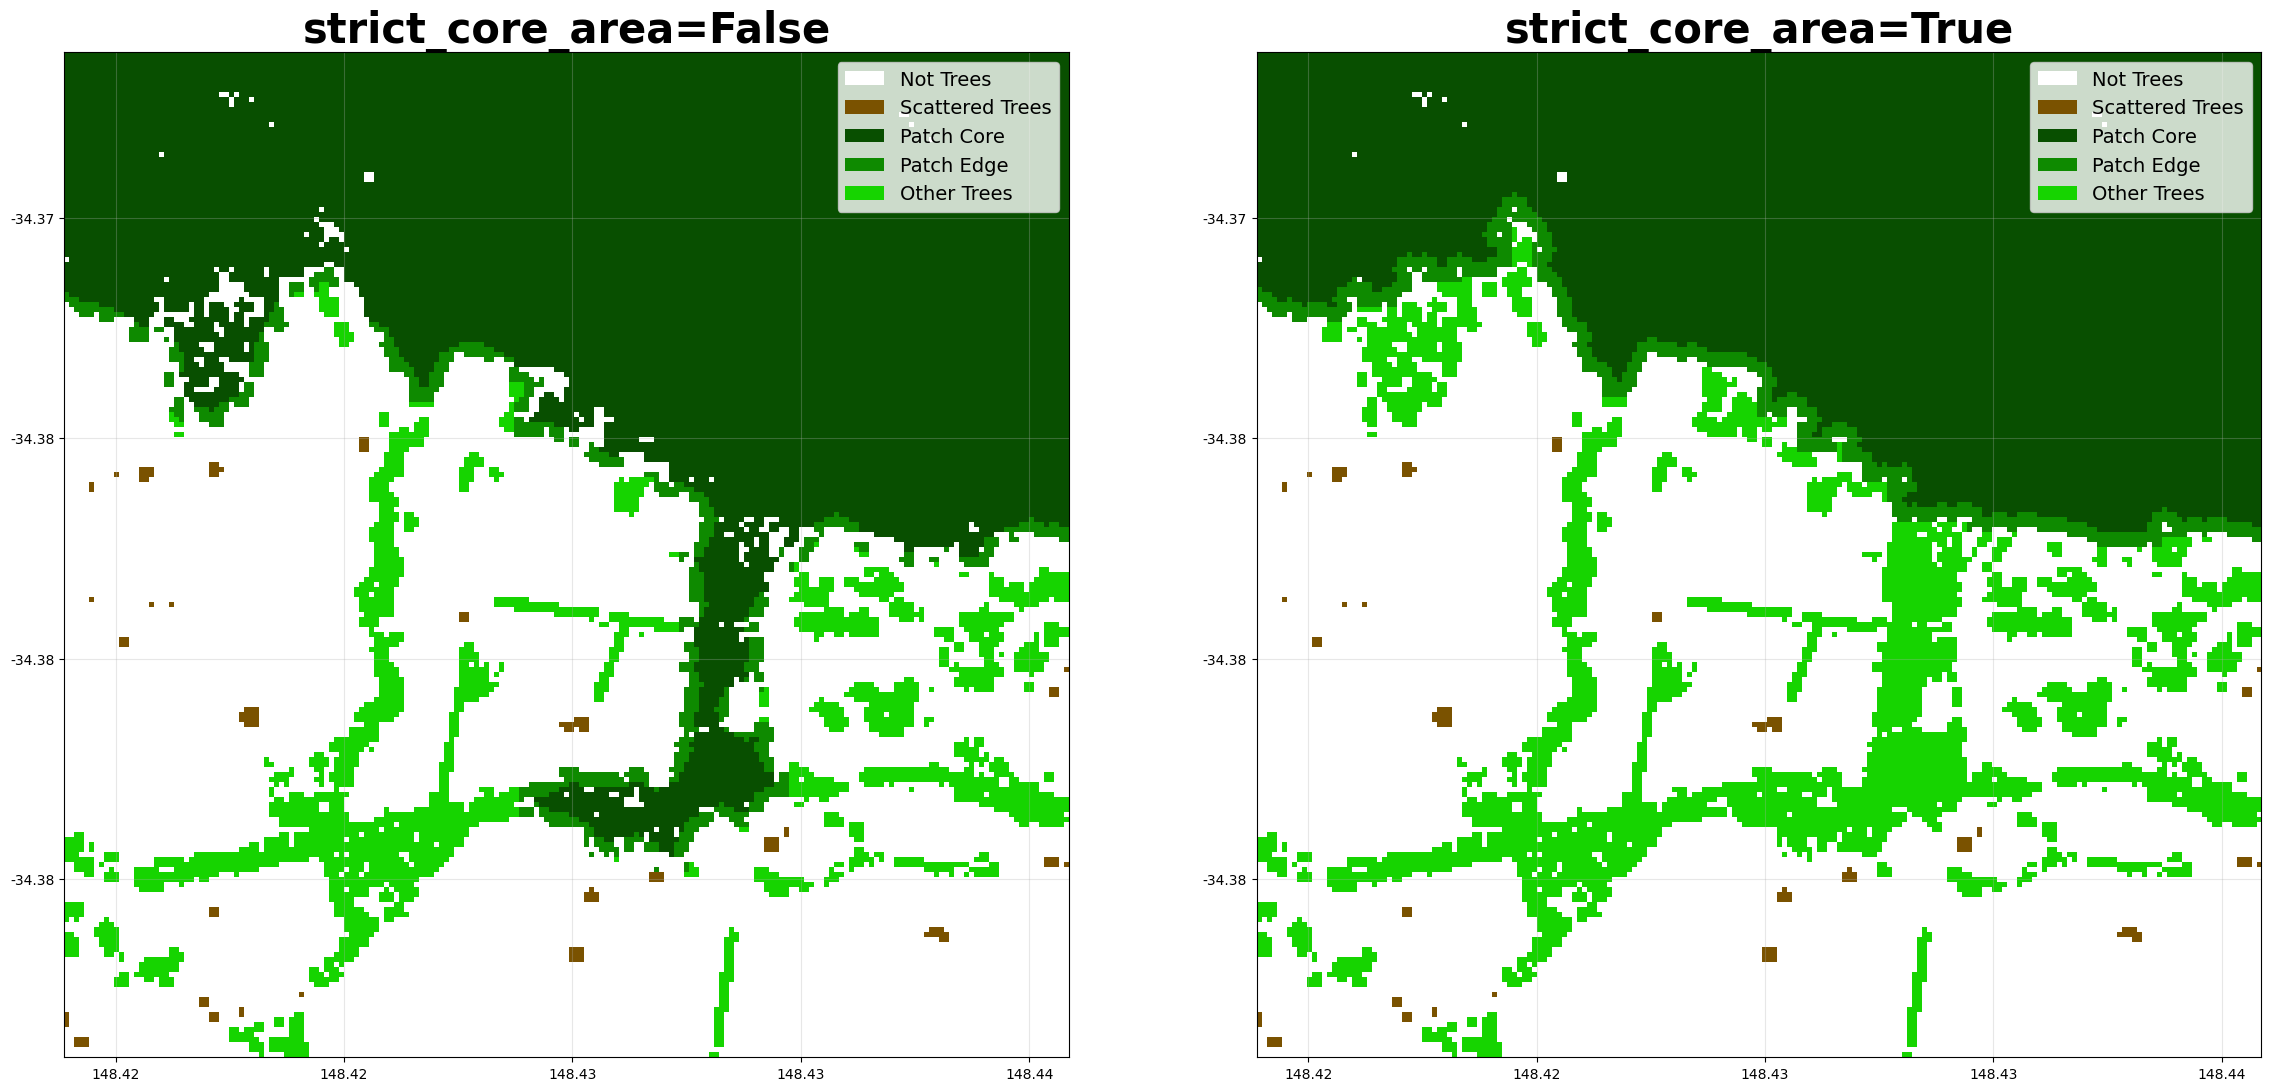

In [7]:
ds_strict_false = tree_categories(ds_input, stub='strict_false', outdir='/tmp', plot=False, save_tif=False, strict_core_area=False)
ds_strict_true = tree_categories(ds_input, stub='strict_true', outdir='/tmp', plot=False, save_tif=False, strict_core_area=True)

visualise_categories_sidebyside(
    ds_strict_false['tree_categories'], ds_strict_true['tree_categories'],
    colormap=tree_categories_cmap, labels=tree_categories_labels,
    title1="strict_core_area=False", title2="strict_core_area=True"
)

## Command Line Interface
You can also use the function from the command line with the same defaults and parameters.

In [8]:
!python -m shelterbelts.indices.tree_categories --help

usage: tree_categories.py [-h] [--outdir OUTDIR] [--stub STUB]
                          [--min_patch_size MIN_PATCH_SIZE]
                          [--min_core_size MIN_CORE_SIZE]
                          [--edge_size EDGE_SIZE]
                          [--max_gap_size MAX_GAP_SIZE]
                          [--no-strict-core-area] [--no-save-tif] [--no-plot]
                          input_data

positional arguments:
  input_data            A binary tif file containing tree/no tree information

options:
  -h, --help            show this help message and exit
  --outdir OUTDIR       Output directory for saving results (default: current
                        directory)
  --stub STUB           Prefix for output filenames (default: derived from
                        input)
  --min_patch_size MIN_PATCH_SIZE
                        Minimum area (pixels) to classify as a patch rather
                        than scattered trees (default: 20)
  --min_core_size MIN_CORE_SIZE
           

In [9]:
%%time
!python -m shelterbelts.indices.tree_categories {binary_tree_file} --stub command_line_defaults

Saved: ./command_line_defaults_tree_categories.tif
Saved: ./command_line_defaults_tree_categories.png
CPU times: user 94.2 ms, sys: 29.5 ms, total: 124 ms
Wall time: 5.08 s


In [10]:
!python -m shelterbelts.indices.tree_categories {binary_tree_file} --min_patch_size 40 --min_core_size 100 --edge_size 2 --max_gap_size 2 --no-strict-core-area --stub command_line

Saved: ./command_line_tree_categories.tif
Saved: ./command_line_tree_categories.png


### Cleanup
Remove the output files created by this notebook

In [11]:
# !rm *.tif
# !rm *.png
# !rm *.xml  # These get generated if you load the tifs in QGIS